# **Data Analysis Project**

## **Importing Python Libaries essential for Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

In [2]:
raw_data = pd.read_csv(r"C:\Users\DELL\Desktop\python\old\Database\1\A_year_of_pizza_sales_from_a_pizza_place_872_68.csv")
raw_data

,Unnamed: 0,X,id,date,time,name,size,type,price
0,1,1,2015-000001,2015-01-01,11:38:36,hawaiian,M,classic,13.25
1,2,2,2015-000002,2015-01-01,11:57:40,classic_dlx,M,classic,16.00
2,3,3,2015-000002,2015-01-01,11:57:40,mexicana,M,veggie,16.00
3,4,4,2015-000002,2015-01-01,11:57:40,thai_ckn,L,chicken,20.75
4,5,5,2015-000002,2015-01-01,11:57:40,five_cheese,L,veggie,18.50
...,...,...,...,...,...,...,...,...,...
49569,49570,49570,2015-021348,2015-12-31,21:23:10,four_cheese,L,veggie,17.95
49570,49571,49571,2015-021348,2015-12-31,21:23:10,napolitana,S,classic,12.00
49571,49572,49572,2015-021348,2015-12-31,21:23:10,ckn_alfredo,M,chicken,16.75
49572,49573,49573,2015-021349,2015-12-31,22:09:54,mexicana,L,veggie,20.25


In [3]:
raw_data.shape

(49574, 9)

In [4]:
raw_data.columns

Index(['Unnamed: 0', 'X', 'id', 'date', 'time', 'name', 'size', 'type',
       'price'],
      dtype='object')

In [5]:
data = raw_data[['X', 'id', 'date', 'time', 'name', 'size', 'type', 'price']].copy()
data

,X,id,date,time,name,size,type,price
0,1,2015-000001,2015-01-01,11:38:36,hawaiian,M,classic,13.25
1,2,2015-000002,2015-01-01,11:57:40,classic_dlx,M,classic,16.00
2,3,2015-000002,2015-01-01,11:57:40,mexicana,M,veggie,16.00
3,4,2015-000002,2015-01-01,11:57:40,thai_ckn,L,chicken,20.75
4,5,2015-000002,2015-01-01,11:57:40,five_cheese,L,veggie,18.50
...,...,...,...,...,...,...,...,...
49569,49570,2015-021348,2015-12-31,21:23:10,four_cheese,L,veggie,17.95
49570,49571,2015-021348,2015-12-31,21:23:10,napolitana,S,classic,12.00
49571,49572,2015-021348,2015-12-31,21:23:10,ckn_alfredo,M,chicken,16.75
49572,49573,2015-021349,2015-12-31,22:09:54,mexicana,L,veggie,20.25


In [6]:
data.columns

Index(['X', 'id', 'date', 'time', 'name', 'size', 'type', 'price'], dtype='object')

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isnull().sum()

X        0
id       0
date     0
time     0
name     0
size     0
type     0
price    0
dtype: int64

In [9]:
data.nunique()

X        49574
id       21350
date       358
time     16382
name        32
size         5
type         4
price       25
dtype: int64

In [10]:
data.name.unique()

array(['hawaiian', 'classic_dlx', 'mexicana', 'thai_ckn', 'five_cheese',
       'ital_supr', 'prsc_argla', 'bbq_ckn', 'the_greek', 'spinach_supr',
       'spin_pesto', 'spicy_ital', 'ital_cpcllo', 'veggie_veg',
       'green_garden', 'southw_ckn', 'pepperoni', 'cali_ckn', 'ckn_pesto',
       'big_meat', 'soppressata', 'four_cheese', 'napolitana',
       'mediterraneo', 'spinach_fet', 'ital_veggie', 'calabrese',
       'peppr_salami', 'sicilian', 'ckn_alfredo', 'pep_msh_pep',
       'brie_carre'], dtype=object)

In [11]:
data['size'].unique()

array(['M', 'L', 'S', 'XL', 'XXL'], dtype=object)

In [12]:
data.type.unique()

array(['classic', 'veggie', 'chicken', 'supreme'], dtype=object)

In [13]:
data.price.unique()

array([13.25, 16.  , 20.75, 18.5 , 16.5 , 12.75, 12.  , 12.5 , 20.5 ,
       20.25, 15.25, 16.75, 17.95, 14.75, 16.25,  9.75, 17.5 , 10.5 ,
       25.5 , 11.  , 14.5 , 12.25, 21.  , 23.65, 35.95])

In [14]:
data.dtypes

X          int64
id        object
date      object
time      object
name      object
size      object
type      object
price    float64
dtype: object

In [15]:
#data['time'] = (pd.to_datetime(data['time'], format='%H:%M:%S').dt..strftime('%H')# for hour alone
#data['time'] = (pd.to_datetime(data['time'], format='%H:%M:%S').dt.hour# for hour alone
#data['time'] = (pd.to_datetime(data['time'], format='%H:%M:%S').dt.strftime('%I%p').str.lstrip('0').str.lower()) # for hour am/pm

In [16]:
datatype_changes = {'id':'string', 'name':'string', 'size':'category', 'type':'category'}
data['date'] = pd.to_datetime(data['date'])
data['time'] = (pd.to_datetime(data['time'], format='%H:%M:%S').dt.strftime('%I%p').str.lstrip('0').str.lower()) # for hour am/pm

data = data.astype(datatype_changes)
data.dtypes

X                 int64
id       string[python]
date     datetime64[ns]
time             object
name     string[python]
size           category
type           category
price           float64
dtype: object

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49574 entries, 0 to 49573
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   X       49574 non-null  int64         
 1   id      49574 non-null  string        
 2   date    49574 non-null  datetime64[ns]
 3   time    49574 non-null  object        
 4   name    49574 non-null  string        
 5   size    49574 non-null  category      
 6   type    49574 non-null  category      
 7   price   49574 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(1), string(2)
memory usage: 2.4+ MB


In [18]:
data.describe()

,X,date,price
count,49574.000000,49574,49574.000000
mean,24787.500000,2015-06-29 12:23:49.136240896,16.497762
min,1.000000,2015-01-01 00:00:00,9.750000
25%,12394.250000,2015-03-31 00:00:00,12.750000
50%,24787.500000,2015-06-28 00:00:00,16.500000
75%,37180.750000,2015-09-28 00:00:00,20.250000
max,49574.000000,2015-12-31 00:00:00,35.950000
std,14310.925459,NaN,3.621954


# **Exploratory Analysis and Visualization**

## **1. Revenue Performance Analysis**

### **1a. Identify total yearly revenue**

In [19]:
total_revenue = data['price'].sum().round(1)
total_revenue

np.float64(817860.0)

In [20]:
print("""
Total Revenue: ${}
""".format(total_revenue))


Total Revenue: $817860.0



### **1b. Track monthly and daily revenue trends**

In [21]:
data['Month'] = data['date'].dt.month_name()
data['Day'] = data['date'].dt.day_name()
data.sample(3)

,X,id,date,time,name,size,type,price,Month,Day
12912,12913,2015-005573,2015-04-04,1pm,the_greek,S,classic,12.00,April,Saturday
26291,26292,2015-011350,2015-07-09,12pm,ckn_alfredo,L,chicken,20.75,July,Thursday
15419,15420,2015-006639,2015-04-22,11am,spinach_fet,L,veggie,20.25,April,Wednesday


In [22]:
sns.set_style('darkgrid')

In [23]:
m_revenue_trend = data.groupby('Month', as_index=False)['price'].sum().round(1)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
m_revenue_trend['Month'] = pd.Categorical(m_revenue_trend['Month'], categories=month_order, ordered=True)
m_revenue_trend = m_revenue_trend.sort_values('Month').reset_index(drop=True)
m_revenue_trend

,Month,price
0,January,69793.3
1,February,65159.6
2,March,70397.1
3,April,68736.8
4,May,71402.8
5,June,68230.2
6,July,72557.9
7,August,68278.2
8,September,64180.0
9,October,64027.6


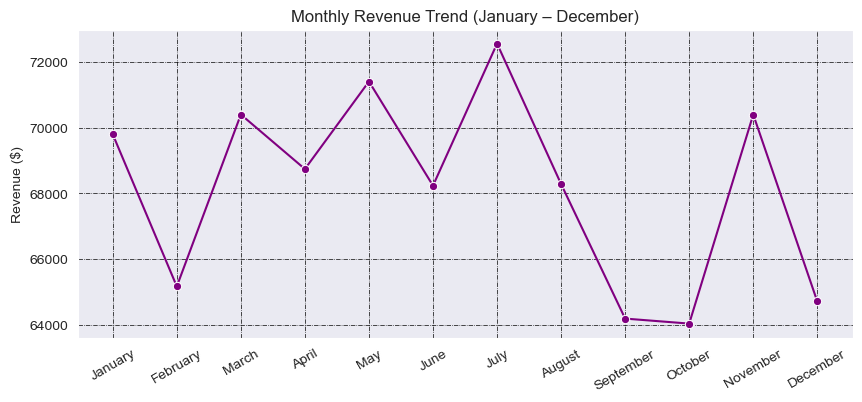

In [24]:
plt.figure(figsize=(10,4))
sns.lineplot(data=m_revenue_trend, x='Month', y='price', marker='o', color='purple')
plt.title('Monthly Revenue Trend (January – December)')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

In [25]:
d_revenue_trend = data.groupby('Day', as_index=False)['price'].sum().round(1)
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
d_revenue_trend['Day'] = pd.Categorical(d_revenue_trend['Day'], categories=day_order, ordered=True)
d_revenue_trend = d_revenue_trend.sort_values('Day').reset_index(drop=True)
d_revenue_trend

,Day,price
0,Sunday,99203.5
1,Monday,107329.6
2,Tuesday,114133.8
3,Wednesday,114408.4
4,Thursday,123528.5
5,Friday,136073.9
6,Saturday,123182.4


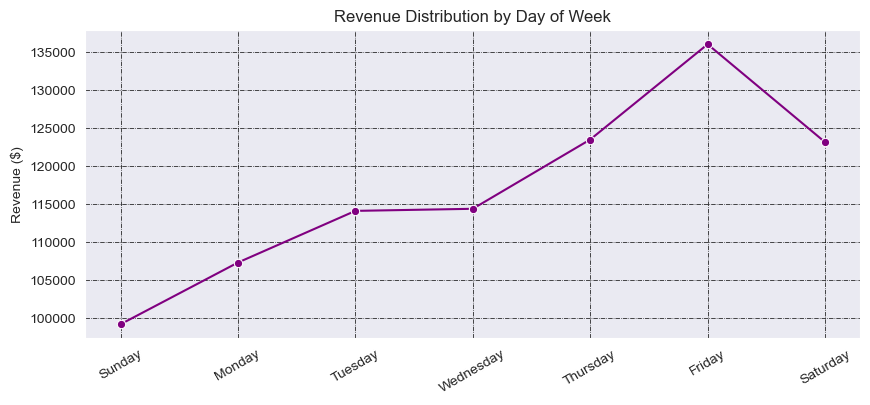

In [26]:
plt.figure(figsize=(10,4))
sns.lineplot(data=d_revenue_trend, x='Day', y='price', marker='o', color='purple')
plt.title('Revenue Distribution by Day of Week')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **1c. Highlight periods of high and low sales**

In [27]:
m_revenue_trend = m_revenue_trend.sort_values('price', ascending=False).reset_index(drop=True)
m_revenue_trend

,Month,price
0,July,72557.9
1,May,71402.8
2,March,70397.1
3,November,70395.4
4,January,69793.3
5,April,68736.8
6,August,68278.2
7,June,68230.2
8,February,65159.6
9,December,64701.2


In [28]:
print("""
1c. Highlight periods of high and low sales

    Top 3 periods of high sales include {}, {} and {}
    while those of low sales include {}, {} and {}
""".format(m_revenue_trend['Month'][0], m_revenue_trend['Month'][1], m_revenue_trend['Month'][2],
          m_revenue_trend['Month'][m_revenue_trend.index[-1]], m_revenue_trend['Month'][m_revenue_trend.index[-2]], 
           m_revenue_trend['Month'][m_revenue_trend.index[-3]]))


1c. Highlight periods of high and low sales

    Top 3 periods of high sales include July, May and March
    while those of low sales include October, September and December



## **2. Product Performance Insights**

### **2a. identify top-selling & least-selling pizzas by revenue**

In [29]:
pizzas_revenue = data.groupby('name', as_index=False)['price'].sum().sort_values('price', ascending=False).reset_index(drop=True)
pizzas_revenue

,name,price
0,thai_ckn,43434.25
1,bbq_ckn,42768.00
2,cali_ckn,41409.50
3,classic_dlx,38180.50
4,spicy_ital,34831.25
5,southw_ckn,34705.75
6,ital_supr,33476.75
7,hawaiian,32273.25
8,four_cheese,32265.70
9,sicilian,30940.50


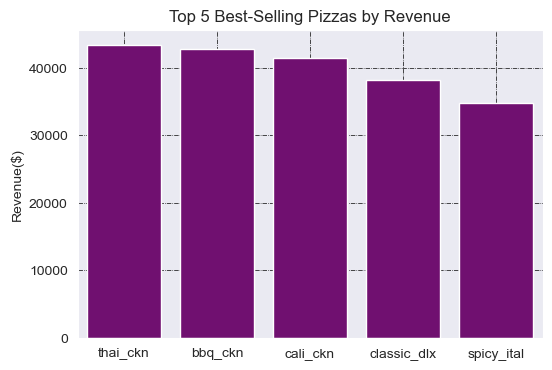

In [30]:
plt.figure(figsize=(6,4))
sns.barplot(data=pizzas_revenue.head(5), x='name', y='price', color='purple')
plt.title('Top 5 Best-Selling Pizzas by Revenue')
plt.xlabel('')
plt.ylabel('Revenue($)')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

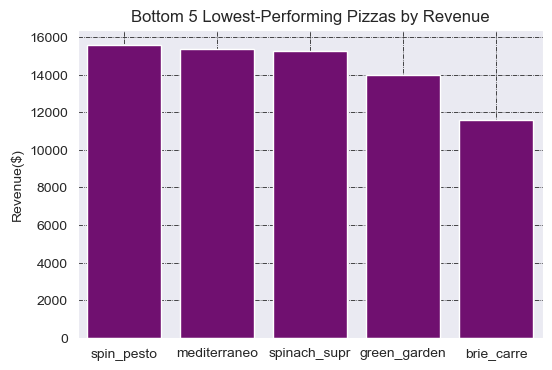

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(data=pizzas_revenue.tail(5), x='name', y='price', color='purple')
plt.title('Bottom 5 Lowest-Performing Pizzas by Revenue')
plt.xlabel('')
plt.ylabel('Revenue($)')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **2b. identify top-performing & underperforming pizzas by quantity**

In [32]:
pizzas_quantity = data.groupby('name', as_index=False).size().sort_values('size', ascending=False).reset_index(drop=True)
pizzas_quantity.sample(3)

,name,size
29,calabrese,937
0,classic_dlx,2453
22,green_garden,997


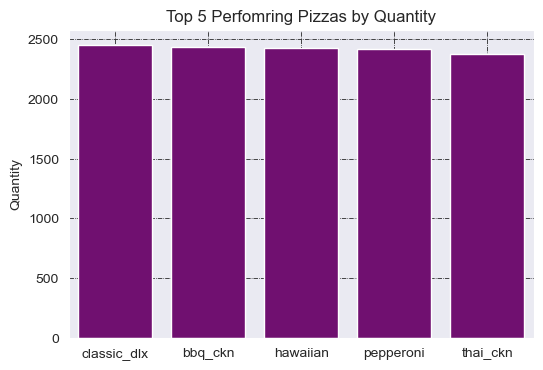

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(data=pizzas_quantity.head(5), x='name', y='size', color='purple')
plt.title('Top 5 Perfomring Pizzas by Quantity')
plt.xlabel('')
plt.ylabel('Quantity')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

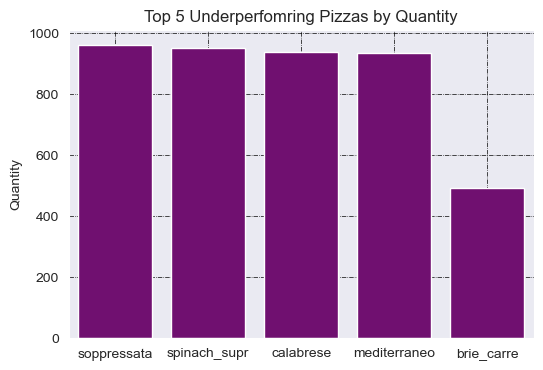

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(data=pizzas_quantity.tail(5), x='name', y='size', color='purple')
plt.title('Top 5 Underperfomring Pizzas by Quantity')
plt.xlabel('')
plt.ylabel('Quantity')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **2c. Compare performance across pizza categories**

In [35]:
pizza_type_revenue = data.groupby('type', as_index=False, observed=False)['price'].sum()
pizza_type_revenue

,type,price
0,chicken,195919.50
1,classic,220053.10
2,supreme,208197.00
3,veggie,193690.45


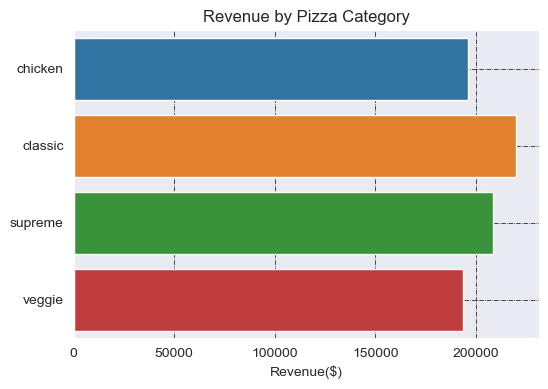

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(data=pizza_type_revenue.head(5), y='type', x='price', hue='type')
plt.title('Revenue by Pizza Category')
plt.xlabel('Revenue($)')
plt.ylabel('')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

## **3. Customer Purchase Behaviour**

### **3a. Analyze most common order times(hour of day)**

In [37]:
common_order_time = data.groupby('time', as_index=False, observed=False).size()
time_order = ['7am', '8am', '9am', '10am', '11am', '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
common_order_time['time'] = pd.Categorical(common_order_time['time'], categories=time_order, ordered=True)
common_order_time = common_order_time.sort_values('time').reset_index(drop=True)
common_order_time

,time,size
0,9am,4
1,10am,18
2,11am,2728
3,12pm,6776
4,1pm,6413
5,2pm,3613
6,3pm,3216
7,4pm,4239
8,5pm,5211
9,6pm,5417


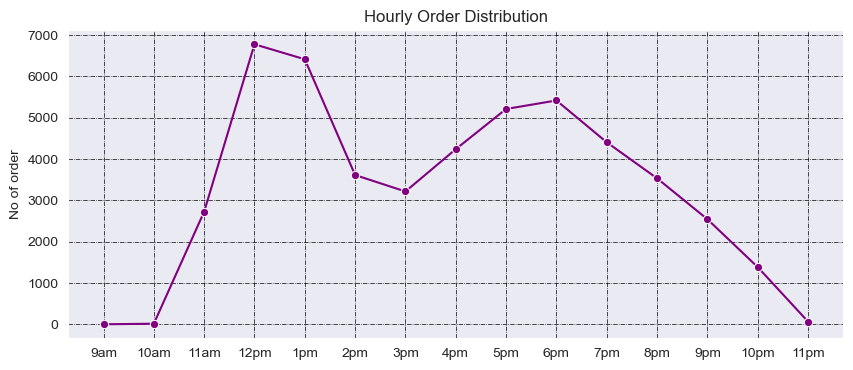

In [38]:
plt.figure(figsize=(10,4))
sns.lineplot(data=common_order_time, x='time', y='size', marker='o', color='purple')
plt.title('Hourly Order Distribution')
plt.xlabel('')
plt.ylabel('No of order')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **3b. Identify peak sales days (weekdays vs weekends)**

In [39]:
peak_sales_day = data.groupby('Day', as_index=False, observed=False).size()
peak_sales_day['Day'] = pd.Categorical(peak_sales_day['Day'], categories=day_order, ordered=True)
peak_sales_day = peak_sales_day.sort_values('Day').reset_index(drop=True)
peak_sales_day

,Day,size
0,Sunday,6035
1,Monday,6485
2,Tuesday,6895
3,Wednesday,6946
4,Thursday,7478
5,Friday,8242
6,Saturday,7493


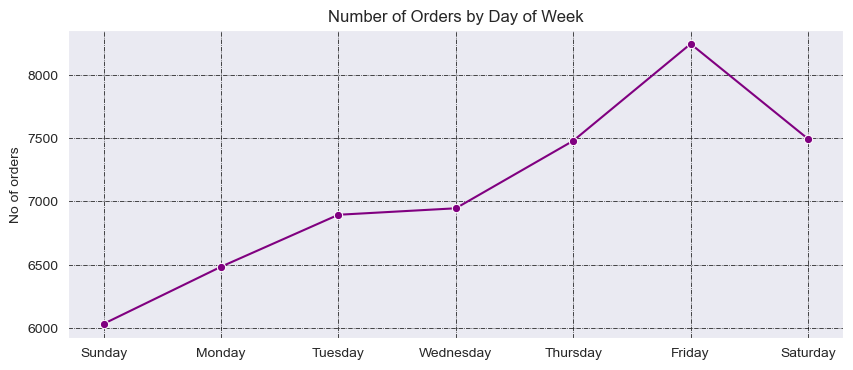

In [40]:
plt.figure(figsize=(10,4))
sns.lineplot(data=peak_sales_day, x='Day', y='size', marker='o', color='purple')
plt.title('Number of Orders by Day of Week')
plt.xlabel('')
plt.ylabel('No of orders')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **3c. Deterimine average order value**

In [41]:
data['price'].mean().round(1)

np.float64(16.5)

In [42]:
print("""
3c. Deterimine average order value
    Answer: ${}
""".format(data['price'].mean().round(1)))


3c. Deterimine average order value
    Answer: $16.5



## **4. Size-Based Sales Analysis**

### **4a. Compare sales distribution across sizes**

In [43]:
data.rename(columns = {'size':'Pizza size'}, inplace=True)

In [44]:
distribution_size = data.groupby('Pizza size', as_index=False, observed=True).size()
distribution_size

,Pizza size,size
0,L,18956
1,M,15635
2,S,14403
3,XL,552
4,XXL,28


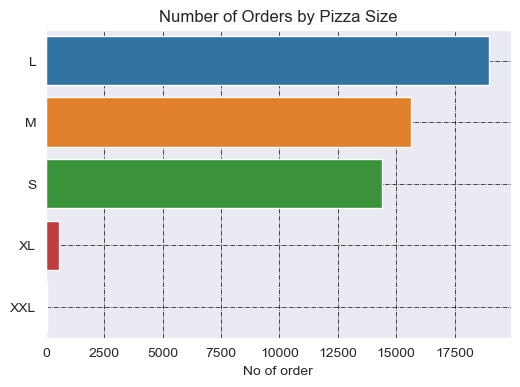

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(data=distribution_size, y='Pizza size', x='size', hue='Pizza size')
plt.title('Number of Orders by Pizza Size')
plt.xlabel('No of order')
plt.ylabel('')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **4b. Identify which size generates the most revenue**

In [46]:
revenue_distribution_size = data.groupby('Pizza size', as_index=False, observed=True)['price'].sum()
revenue_distribution_size

,Pizza size,price
0,L,375318.70
1,M,249382.25
2,S,178076.50
3,XL,14076.00
4,XXL,1006.60


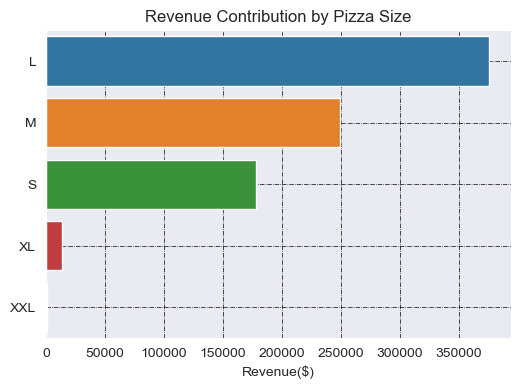

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(data=revenue_distribution_size, y='Pizza size', x='price', hue='Pizza size')
plt.title('Revenue Contribution by Pizza Size')
plt.xlabel('Revenue($)')
plt.ylabel('')
plt.grid(color='black',  linestyle='-.', linewidth='0.5');

### **4c. Evaluate if pricing aligns with demand**

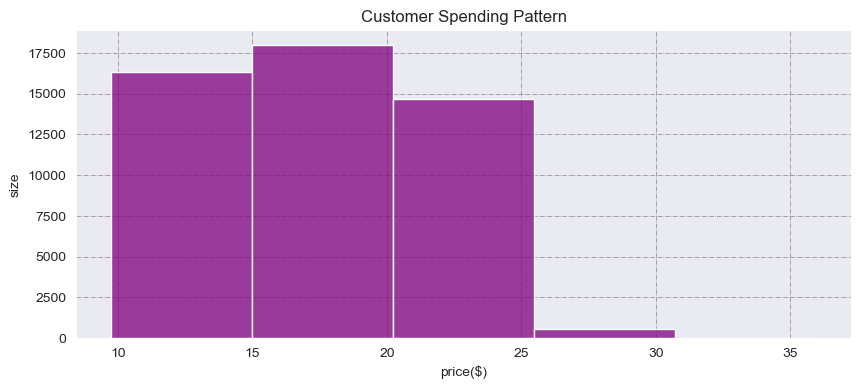

In [48]:
plt.figure(figsize=(10,4))
sns.histplot(data=data, x='price', bins=5, color='purple')
plt.title('Customer Spending Pattern')
plt.xlabel('price($)')
plt.ylabel('size')
plt.grid(color='grey',  linestyle='-.', linewidth='0.5');

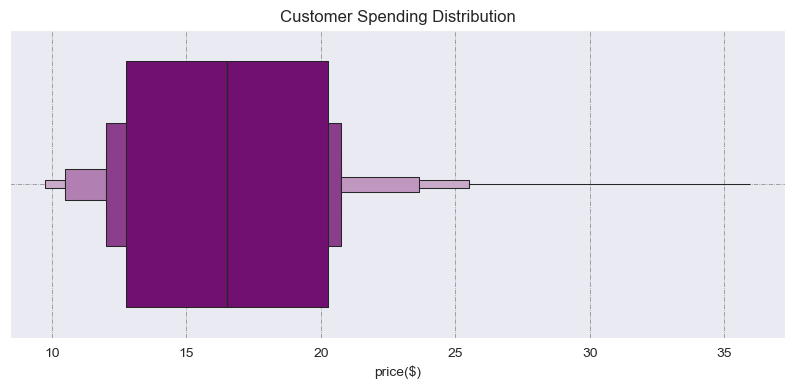

In [49]:
plt.figure(figsize=(10,4))
sns.boxenplot(data=data, x='price', color='purple')
plt.title('Customer Spending Distribution')
plt.xlabel('price($)')
#plt.ylabel('size')
plt.grid(color='grey',  linestyle='-.', linewidth='0.5');

## **5. Category Contribution to revenue**

## **5a. Measure revenue Contribution by Category**

In [50]:
category_revenue = data.groupby('type', as_index=False, observed=True)['price'].sum()
category_revenue

,type,price
0,chicken,195919.50
1,classic,220053.10
2,supreme,208197.00
3,veggie,193690.45


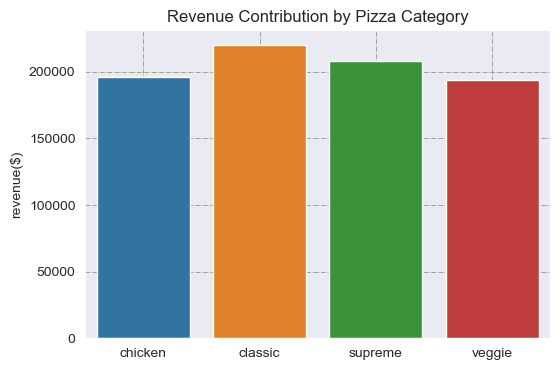

In [51]:
plt.figure(figsize=(6,4))
sns.barplot(data=category_revenue, x='type', y='price', hue='type')
plt.title('Revenue Contribution by Pizza Category')
plt.xlabel('')
plt.ylabel('revenue($)')
plt.grid(color='grey',  linestyle='-.', linewidth='0.5');

### **5b. Identify the most profitable category**

### **5c. Compare category popularity vs revenue**

In [52]:
category_popularity = data.groupby('type', as_index=False, observed=True).size()
category_popularity

,type,size
0,chicken,11050
1,classic,14888
2,supreme,11987
3,veggie,11649


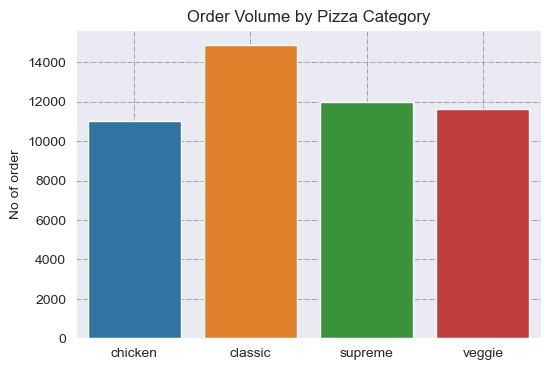

In [53]:
plt.figure(figsize=(6,4))
sns.barplot(data=category_popularity, x='type', y='size', hue='type')
plt.title('Order Volume by Pizza Category')
plt.xlabel('')
plt.ylabel('No of order')
plt.grid(color='grey',  linestyle='-.', linewidth='0.5');

In [54]:
data.sample(3)

,X,id,date,time,name,Pizza size,type,price,Month,Day
33108,33109,2015-014353,2015-08-28,12pm,pepperoni,M,classic,12.50,August,Friday
27438,27439,2015-011845,2015-07-17,4pm,four_cheese,M,veggie,14.75,July,Friday
12907,12908,2015-005572,2015-04-04,1pm,southw_ckn,M,chicken,16.75,April,Saturday


In [55]:
data.to_csv(r'C:\Users\DELL\Desktop\python\old\Database\1\pizza_sales_performance.csv', index=None, header=True)


In [56]:
os.listdir(r'C:\Users\DELL\Desktop\python\old\Database\1')

['A_year_of_pizza_sales_from_a_pizza_place_872_68.csv',
 'pizza_sales_performance.csv',
 'python_cleaned_pizza_sales_dataset.csv']